LAB01 - Tarefa 02

Vamos agora analisar a escolha do hiperparâmetro k do algoritmo k-NN. Para esta análise baixar o arquivo Lab01Tarefa02 disponibilizado na nossa Comunidade da disciplina no Moodle©. Basicamente iniciaremos o algoritmo com vários valores de k e acompanharemos os erros. Em função do gráfico obtido selecionar o melhor valor de k e refazer a Tarefa ii. Abrir o ambiente de programação Python, utilizar o código disponibilizado no arquivo e analisar o mesmo. A principal questão: a seleção do hiperparâmetro impactou no resultado?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Carrega minha pasta do GoogleDrive onde está localizada a base de dados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dados=pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Dados - Especialização/heart.csv')
dados.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
X = dados.iloc[:,:-1]
y = dados.iloc[:,-1]

In [5]:
from sklearn.model_selection import train_test_split
X_trein, X_teste, y_trein, y_teste = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [6]:
from sklearn.neighbors import KNeighborsClassifier
classificador = KNeighborsClassifier(n_neighbors = 1)
classificador.fit(X_trein, y_trein)

KNeighborsClassifier(n_neighbors=1)

In [7]:
y_pred = classificador.predict(X_teste)
from sklearn.metrics import confusion_matrix, classification_report
print ('\n')
print(confusion_matrix(y_teste, y_pred))
print('\n')
print(classification_report(y_teste, y_pred))



[[12 21]
 [15 28]]


              precision    recall  f1-score   support

           0       0.44      0.36      0.40        33
           1       0.57      0.65      0.61        43

    accuracy                           0.53        76
   macro avg       0.51      0.51      0.50        76
weighted avg       0.52      0.53      0.52        76



Text(0, 0.5, 'Erro')

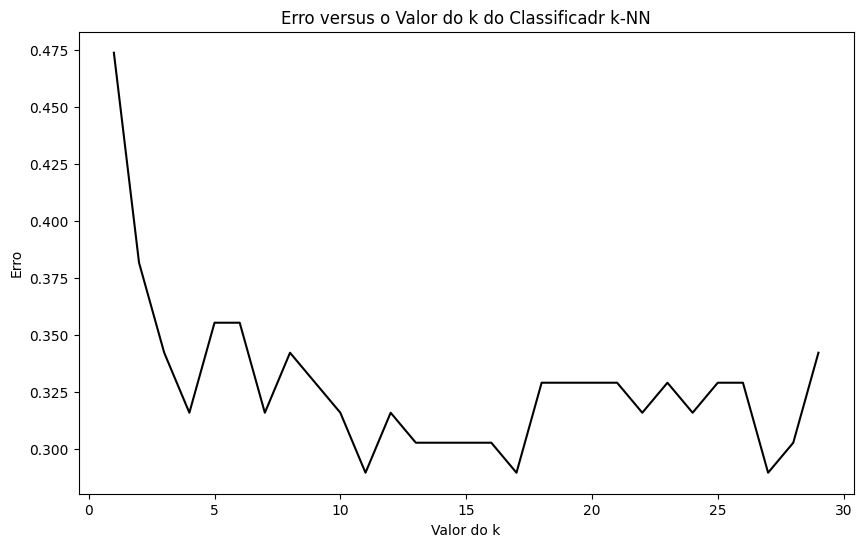

In [8]:
import numpy as np
erros = []
for i in range (1,30):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_trein, y_trein)
    pred_i = knn.predict(X_teste) # pred_i = saída predita do modelo
    erros.append(np.mean(pred_i != y_teste))
plt.figure(figsize=(10,6))
plt.plot(range(1,30), erros, color='black')
plt.title('Erro versus o Valor do k do Classificadr k-NN')
plt.xlabel('Valor do k')
plt.ylabel('Erro')